In [1]:
import batsim
import galsim
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] ='cm'
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('axes', unicode_minus=False)
plt.rc('axes.formatter', use_mathtext=True)

# Georgiou 2019 best-fit

In this notebook, we carry out the best fit to the results of [Georgiou 2019](https://www.aanda.org/articles/aa/full_html/2019/08/aa35810-19/aa35810-19.html) which is used to set the default parameters of our non-affine IA shear model.

We then go on to show a few examples of how different parameter choices change the resulting shear profile.

In [2]:
# Parameters from G19
r_scale = np.array([0.5, 1.0, 1.25, 1.5, 2.0]) # weight function of estimator
r_iso = np.array([1.33, 2.66, 3.32, 3.99, 5.32]) # isophote radius (3-sigma)
A_obs = np.array([2.17e-4, 2.95e-4, 4.33e-4, 5.92e-4, 7.84e-4]) # measured alignment amplitude
sig_A = np.array([8.5e-5, 9.2e-5, 1.06e-4, 1.20e-4, 1.63e-4]) # error in alignment amplitude

r_wf = r_scale * r_iso

# Construct power law model to fit to the data
def A_model(r, A0, beta):
    return A0 * r**beta

# Fit the model to the data
popt, pcov = curve_fit(A_model, r_scale, A_obs, sigma=sig_A, absolute_sigma=True)

r_scale_fit = np.linspace(0.5, 2.0, 100)
A_fit = A_model(r_scale_fit, *popt)
A_upper = A_model(r_scale_fit, *(popt + np.sqrt(np.diag(pcov))))
A_lower = A_model(r_scale_fit, *(popt - np.sqrt(np.diag(pcov))))

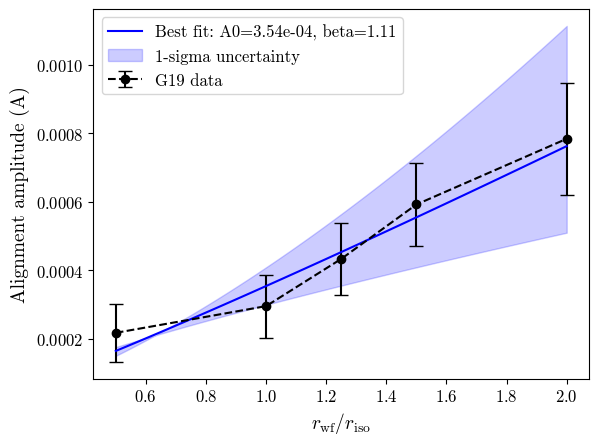

In [3]:
plt.errorbar(r_scale, A_obs, yerr=sig_A, marker='o', capsize=5, label='G19 data', color='black', ls='--')
plt.plot(r_scale_fit, A_fit, label=f'Best fit: A0={popt[0]:.2e}, beta={popt[1]:.2f}', color='blue')
plt.fill_between(r_scale_fit, A_lower, A_upper, color='blue', alpha=0.2, label='1-sigma uncertainty')
plt.xlabel(r'$r_{\rm wf}/r_{\rm iso}$', fontsize=14)
plt.ylabel(r'Alignment amplitude (A)', fontsize=14)
#plt.title('Best Fit of Alignment Amplitude vs Weight Function Scale')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12)
plt.savefig('IA_model_G19_bestfit.pdf', dpi=300, bbox_inches='tight')

## Applying G19 fit to simulations

As discussed in the release paper, we make a phenonmenological reparameterisation of the model fit to G19 in order to use it within BATSim for generating shear values. This is done by replacing $r_{wf}/r_{iso}$ with $r/r_{hlr}$ where $r$ is distance from the centre of the galaxy and $r_{hlr}$ is half-light radius.

It is important to note that typically $r_{iso}$ is larger than $r_{hlr}$. As such, the model employed in BATSim is intended only to reproduce the observed trend in alignment signal with galaxy radius.

For simplicity and to clearly demonstrate the shear pattern created by this model, we show the shear values produced by the model on a quiver plot grid and apply the transfrom to an initially circular galaxy.

4096 4096
4096 [-0.00211141 -0.00211141 -0.00211141 ... -0.00211141 -0.00211141
 -0.00211141]


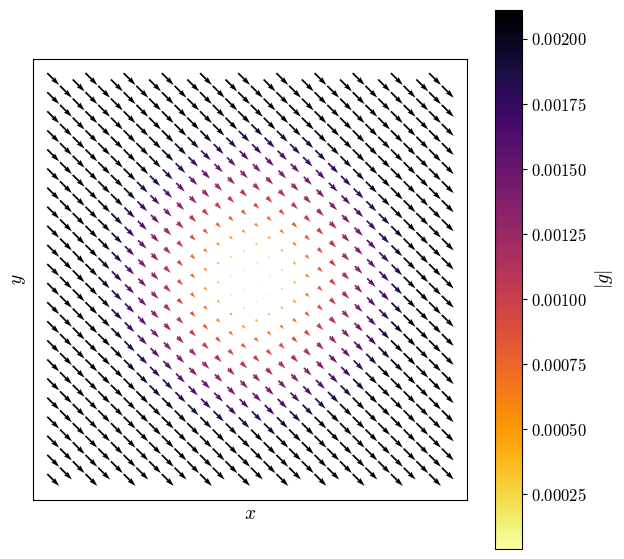

In [4]:
# set image parameters
pix_scale = 0.2
npix = 64

# set galaxy hlr to be used in the IA model
hlr = 1.0
pos_angle = -45.0

# construct transfrom object
ia_transform = batsim.IATransform(
    A=popt[0],
    scale=pix_scale,
    hlr=hlr,
    phi=np.radians(pos_angle)
)

# construct coordinate stamp
stamp = batsim.Stamp(nn=npix, scale=pix_scale)
coords = stamp.coords
x = coords[0]
y = coords[1]

print(len(x), len(y))

# get shear values at each set of coords from IA transfrom object
g1, g2 = ia_transform.get_g1g2(x, y)

print(len(g1), (g2))

g_abs = np.hypot(g1, g2)
phi_plot = 0.5 * np.arctan2(g2, g1)

u = g_abs * np.cos(phi_plot)
v = g_abs * np.sin(phi_plot)

# Downsample to avoid plotting 4096 overlapping arrows.
step = 6

# Quiver plot
fig, ax = plt.subplots(figsize=(7, 7))

q = ax.quiver(
    x[::step],
    y[::step],
    u[::step],
    v[::step],
    np.hypot(u[::step], v[::step]),
    angles="xy",
    scale_units="xy",
    scale=0.004, # smaller scale produces longer arrows
    width=0.004, # smaller width produces thinner arrows
    cmap="inferno_r",
    pivot="middle",
)

ax.set_aspect("equal")
ax.set_xlabel(r"$x$", fontsize=14)
ax.set_ylabel(r"$y$", fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
cb = fig.colorbar(q, ax=ax, label=r"$|g|$")
cb.set_label(r"$|g|$", fontsize=14)
cb.ax.tick_params(labelsize=12)
fig.savefig('IA_model_G19_quiver.pdf', dpi=300, bbox_inches='tight')

plt.show()

In this set-up, we set the alignment orientation to be towards the bottom left of the image. We use the default G19 best fit values. This results in peak shear values on the order of $10^{-3}$.

The length and colour of the arrows in the quiver plot represent the strength of the shear.

In [5]:
# Apply transform to a galaxy image and plot residuals
gal = galsim.Gaussian(half_light_radius=hlr)

# Simulate galaxy image with IA transform using BATSim
gal_ia_image = batsim.simulate_galaxy(
    gal_obj=gal,
    transform_obj=ia_transform,
    scale=pix_scale,
    ngrid=npix
)

# Draw the galaxy image without IA transform for comparison
gal_noia_image = gal.drawImage(nx=npix, ny=npix, scale=pix_scale)

# Compute the residual image
ia_residual_image = gal_ia_image - gal_noia_image.array

plt.figure(figsize=(7,7))
plt.imshow(ia_residual_image, origin='lower', cmap='gray', extent=[-npix/2*pix_scale, npix/2*pix_scale, -npix/2*pix_scale, npix/2*pix_scale])
plt.xticks([])
plt.yticks([])

phi = np.deg2rad(pos_angle)

length = 2.0
dx = length * np.cos(phi)
dy = length * np.sin(phi)

plt.plot(
    [-dx, dx],
    [-dy, dy],
    "r--",
    label=r"Input alignment axis $\phi$",
)

plt.legend(fontsize=12)

RuntimeError: simulate_galaxy failed cleanly after releasing backend memory (ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all())

The final plot shows the absolute flux difference between an IA transfromed BATSim image and an unsheared GalSim reference. Brighter pixels contain more flux than the reference and darker pixels less.

NameError: name 'step' is not defined

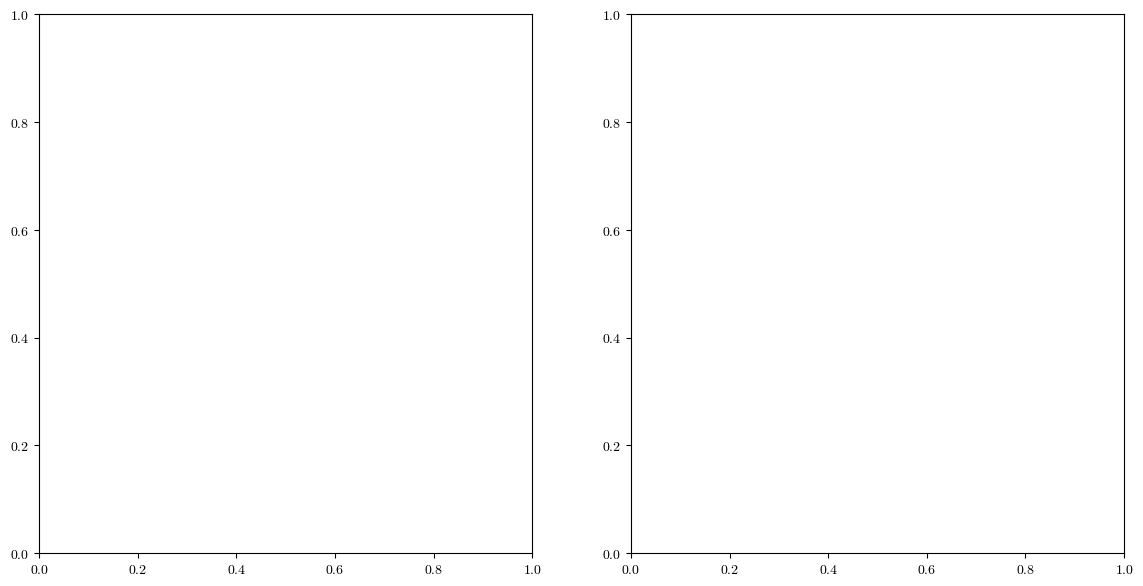

In [ ]:
# Combine quiver and residual plots into a single figure
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
# Quiver plot
q = axs[0].quiver(
    x[::step],
    y[::step],
    u[::step],
    v[::step],
    np.hypot(u[::step], v[::step]),
    angles="xy",
    scale_units="xy",
    scale=0.004, # smaller scale produces longer arrows
    width=0.004, # smaller width produces thinner arrows
    cmap="inferno_r",
    pivot="middle",
)

axs[0].set_aspect("equal")
axs[0].set_xlabel(r"$x$", fontsize=14)
axs[0].set_ylabel(r"$y$", fontsize=14)
axs[0].set_xticks([])
axs[0].set_yticks([])
cb = fig.colorbar(q, ax=axs[0], label=r"$|g|$")
cb.set_label(r"$|g|$", fontsize=14)
cb.ax.tick_params(labelsize=14)

# Residual plot
axs[1].imshow(ia_residual_image, origin='lower', cmap='viridis', extent=[-npix/2*pix_scale, npix/2*pix_scale, -npix/2*pix_scale, npix/2*pix_scale])
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_xlabel(r"$x$", fontsize=14)
axs[1].set_ylabel(r"$y$", fontsize=14)
cb = fig.colorbar(axs[1].imshow(ia_residual_image, origin='lower', cmap='viridis', extent=[-npix/2*pix_scale, npix/2*pix_scale, -npix/2*pix_scale, npix/2*pix_scale]), ax=axs[1], label=r"Residual")
cb.set_label(r"Residual", fontsize=14)
cb.ax.tick_params(labelsize=14)

phi = np.deg2rad(pos_angle)
length = 2.0
dx = length * np.cos(phi)
dy = length * np.sin(phi)

axs[1].plot(
    [-dx, dx],
    [-dy, dy],
    "r--",
    label=r"Input alignment axis $\phi$",
)
axs[1].legend(fontsize=14)

plt.tight_layout()
plt.savefig('IA_model_G19_quiver_residual.pdf', dpi=300, bbox_inches='tight')
plt.show()